# K-Means 代码实现

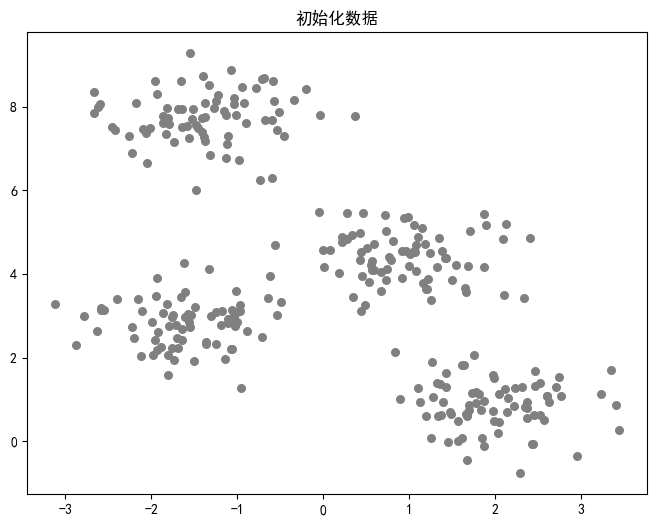

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs

plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

np.random.seed(42)
X, y_true = make_blobs(
  n_samples=300,
  centers=4,
  cluster_std=0.6,
  random_state=0,
)

plt.figure(figsize=(8,6))
plt.scatter(X[:,0], X[:,1], s = 30, c='gray')
plt.title("初始化数据")
plt.show()

In [21]:
k = 4
# 随机选择k个点作初始中心
ini_idx = np.random.choice(X.shape[0], k, replace=False)
centers = X[ini_idx]

# 定义绘图函数
def plot_kmean(x, centers, labels = None, title = ""):
  # 定义画幅
  plt.figure(figsize=(8,6))
  # 有标签时绘制样本
  if labels is not None:
    plt.scatter(
      x[:,0], x[:,1], 
      c= labels, s = 30, 
      cmap = 'viridis',
      alpha=0.6, 
      )
  # 无标签时绘制中心
  else:
    plt.scatter(
      x[:,0],x[:,1],
      s=30, c='gray',
      alpha=0.6
      )
  
  # 绘制中心点
  plt.scatter(
    centers[:,0], centers[:,1],
    c='red', s=200,
    marker='x',
    edgecolors='black',
    )
  plt.title(title)
  plt.show()
  

C:\Users\Gold\AppData\Local\Temp\ipykernel_335968\1367093426.py:27: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(


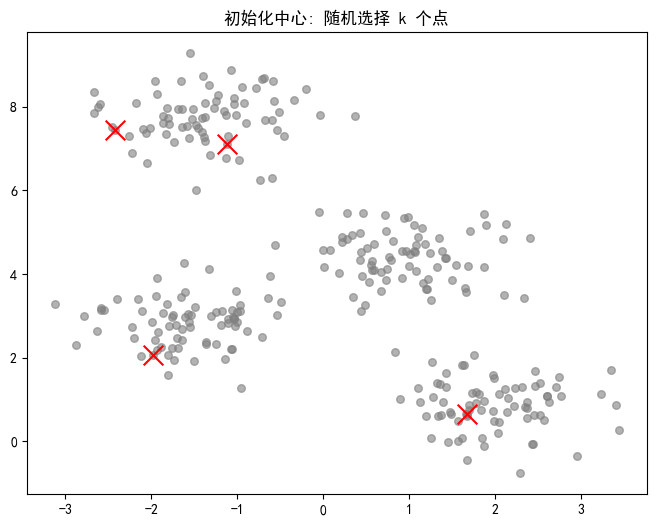

In [22]:
plot_kmean(X, centers, title="初始化中心: 随机选择 k 个点")
max_iters = 15


C:\Users\Gold\AppData\Local\Temp\ipykernel_335968\3789080329.py:9: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(centers[:,0],centers[:,1], c='red', s=200, marker='x',edgecolors='black')
C:\Users\Gold\AppData\Local\Temp\ipykernel_335968\3789080329.py:16: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(new_centers[:,0], new_centers[:,1], c='red', s=200, marker='x', edgecolors='black')
C:\Users\Gold\AppData\Local\Temp\ipykernel_335968\1367093426.py:27: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(


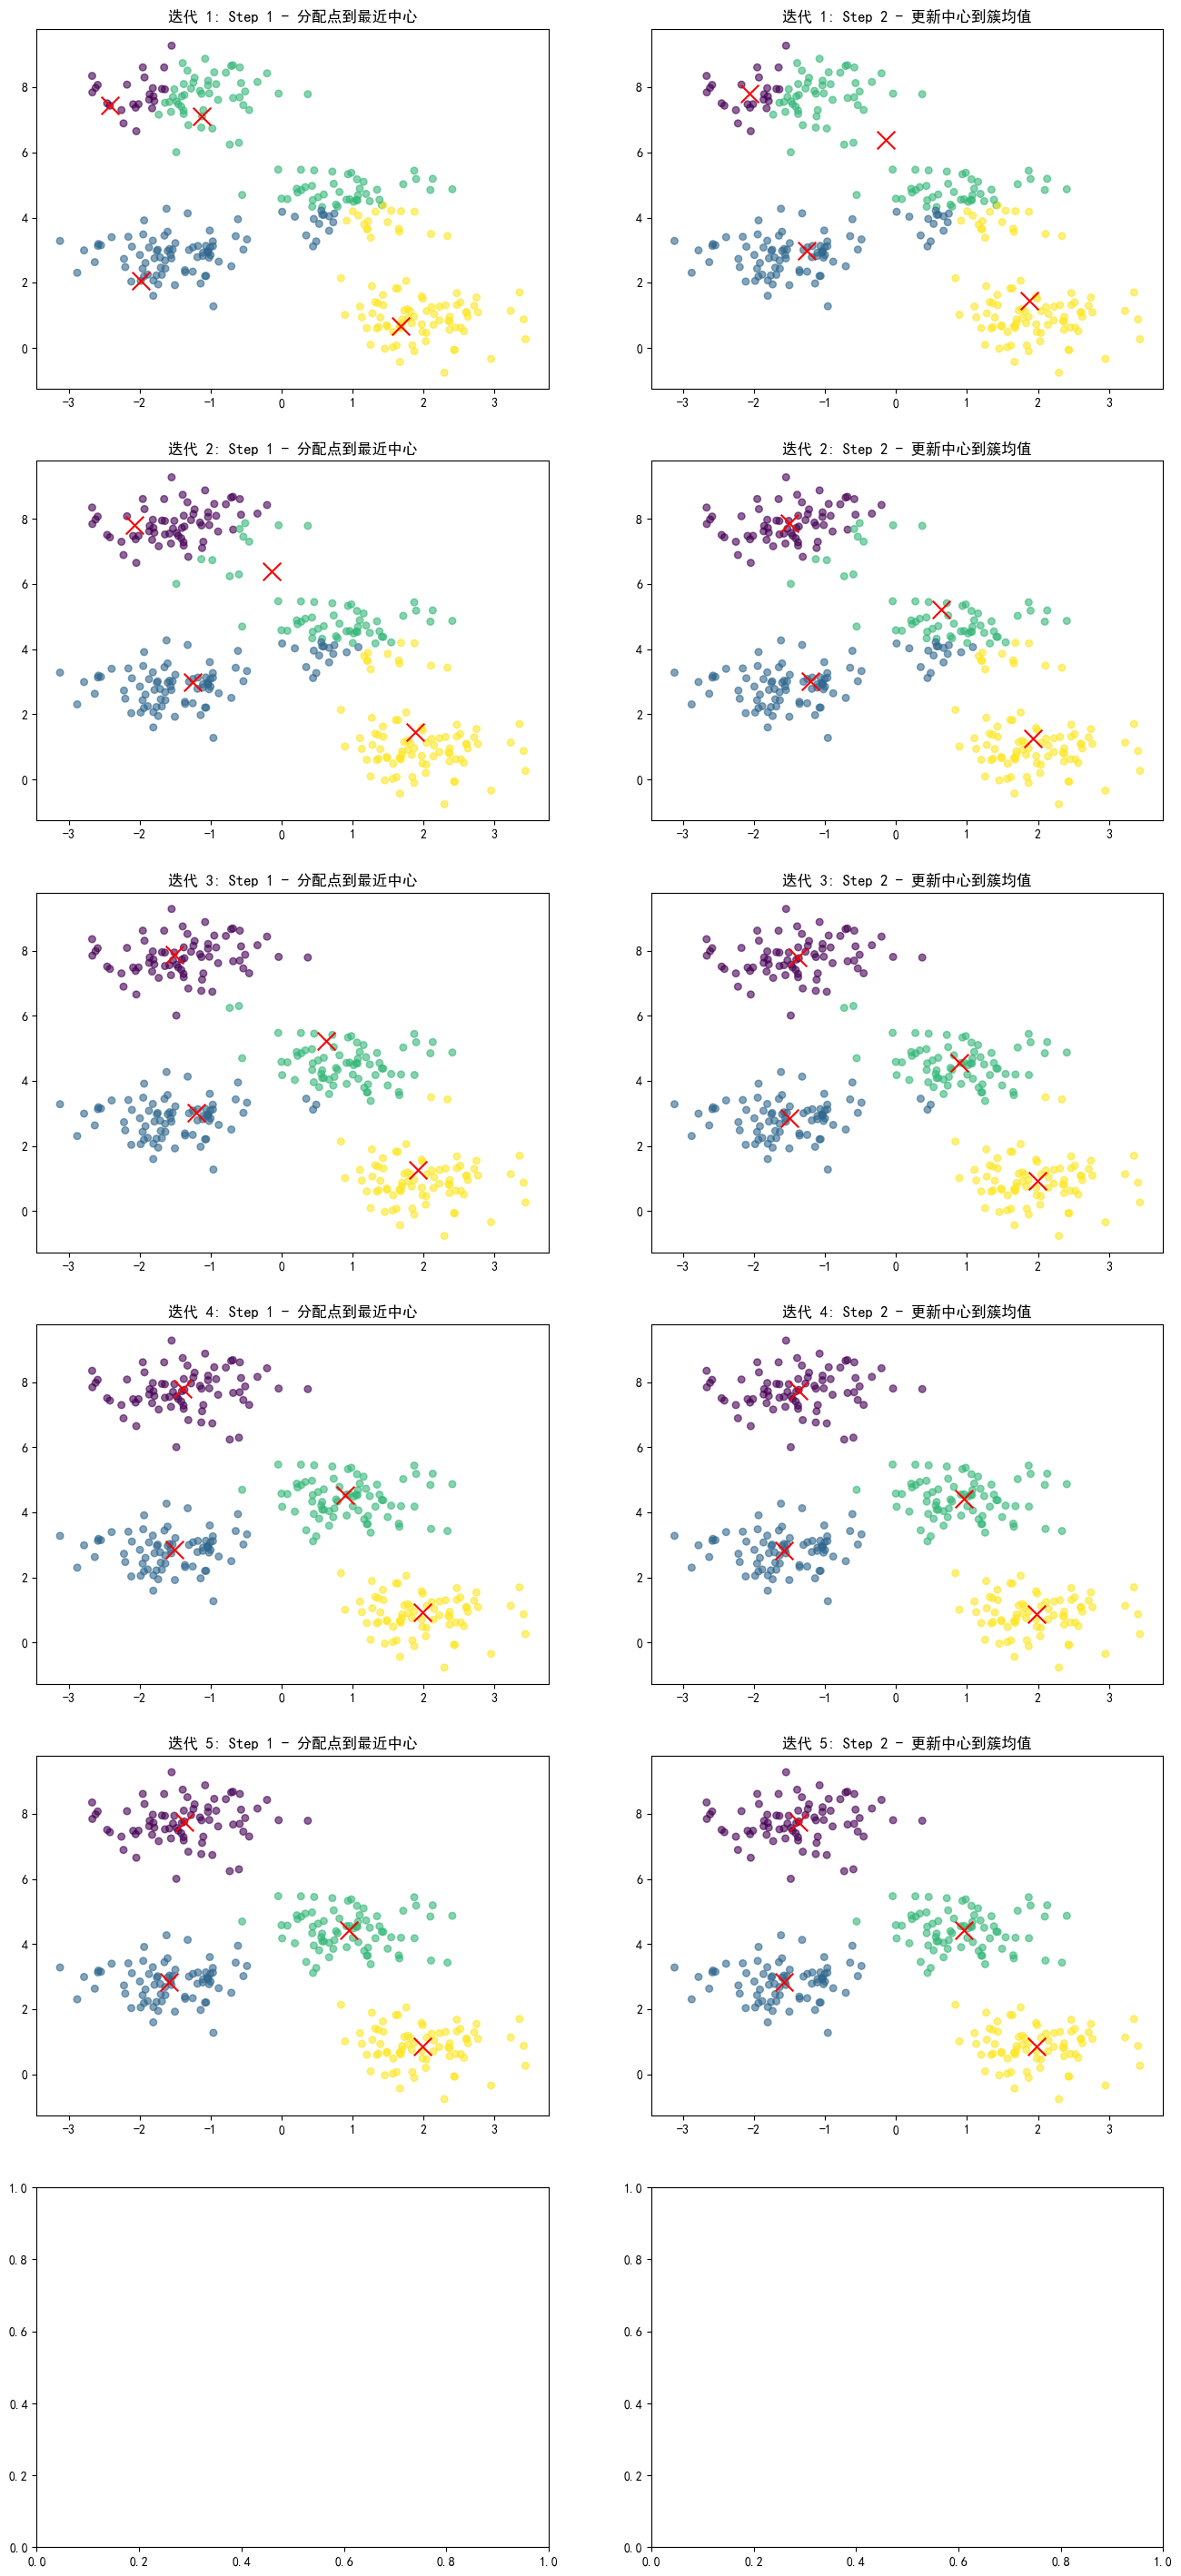

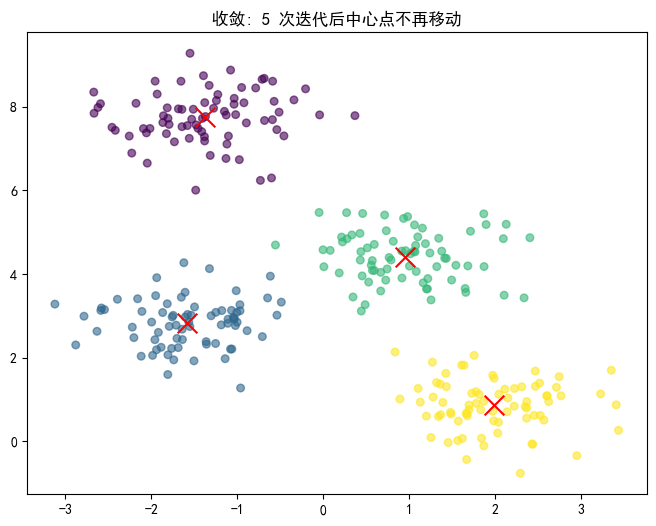

算法在 5 次迭代后完全收敛! 中心点不再移动。


<Figure size 640x480 with 0 Axes>

In [23]:
from scipy.spatial.distance import cdist
fig, axes = plt.subplots(6,2, figsize = (16,36))
for i in range(max_iters):
  # 分配标签
  distances = cdist(X, centers)
  labels = np.argmin(distances, axis=1)
  ax = axes[i][0]
  ax.scatter(X[:,0], X[:,1], c = labels, s=30, cmap='viridis', alpha=.6)
  ax.scatter(centers[:,0],centers[:,1], c='red', s=200, marker='x',edgecolors='black')
  ax.set_title(f"迭代 {i+1}: Step 1 - 分配点到最近中心")

  # 更新中心
  new_centers = np.array([X[labels == j].mean(axis=0) for j in range(k)])
  ax = axes[i][1]
  ax.scatter(X[:,0], X[:,1], c = labels, s=30, cmap='viridis', alpha=.6)
  ax.scatter(new_centers[:,0], new_centers[:,1], c='red', s=200, marker='x', edgecolors='black')
  ax.set_title(f"迭代 {i+1}: Step 2 - 更新中心到簇均值")

  # 检查收敛
  if np.all(centers == new_centers):
    plot_kmean(X, new_centers, labels, title=f"收敛: {i+1} 次迭代后中心点不再移动")
    print(f"算法在 {i+1} 次迭代后完全收敛! 中心点不再移动。")
    break

  centers = new_centers

# 绘图
plt.suptitle('K-Means 逐轮迭代', fontsize = 12, fontweight = 'bold')
plt.tight_layout()
plt.show()

## 初始化数据

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs

plt.rcParams['font.sans-serif'] = ['SimHei'] # 用来正常显示中文标签
plt.rcParams['axes.unicode_minus'] = False  # 用来正常显示负号

# 设置随机种子以保证结果可重复
np.random.seed(42)

# 1. 生成模拟数据
# 生成300个样本，分为4个簇
X, y_true = make_blobs(n_samples=300, centers=4, cluster_std=0.60, random_state=0)

plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], s=30, color='gray')
plt.title("初始化数据")
plt.show()

## 迭代过程

In [ ]:
import time
from scipy.spatial.distance import cdist
from IPython.display import clear_output

# 随机选择 k 个点作为初始中心
k = 4 
initial_indices = np.random.choice(X.shape[0], k, replace = False)
centroids = X[initial_indices]


In [ ]:
# 定义绘图函数
def plot_kmeans_step(x, centroids, labels = None, title =""):
  plt.figure(figsize=(8,6))
  if labels is not None:
    plt.scatter(x[:,0], x[:,1], c= labels, s= 30, cmap= 'viridis', alpha= 0.6)
  else:
    plt.scatter(x[:,0], x[:,1], s=30, color= 'gray', alpha=0.6)

  # 绘制中心点
  plt.scatter(centroids[:,0], centroids[:,1], c='red', s=200, marker='x', edgecolors='black')
  plt.title(title)
  plt.show()


In [ ]:
# 初始状态展示
plot_kmeans_step(X, centroids, title="初始化中心: 随机选择 k 个点")
time.sleep(1.5)

max_iters = 15
for i in range(max_iters):
  # --- 步骤 1: 分配 Assignment ---
  distances = cdist(X, centroids)         # 计算 每个样本点 到 每个中心点 的距离
  labels = np.argmin(distances, axis = 1) # 对每一行(每个点)找最小值的位置

  clear_output(wait=True)
  plot_kmeans_step(X, centroids, labels, title=f"迭代 {i+1}: Step 1 - 分配点到最近中心")
  time.sleep(1.5)

  # --- 步骤 2: 更新 Update ---
  new_centroids = np.array([X[labels == j].mean(axis=0) for j in range(k)])

  clear_output(wait=True)
  plot_kmeans_step(X, new_centroids, labels, title=f"迭代 {i + 1}: step 2 - 更新中心到簇均值")
  time.sleep(1.5)

  # --- 检查收敛 ---
  if np.all(centroids == new_centroids):
    clear_output(wait=True)
    plot_kmeans_step(X, new_centroids, labels, title=f"收敛: {i+1} 次迭代后中心点不再移动")
    print(f"算法在第 {i + 1} 次迭代后完全收敛！中心点不再移动。")
    break

  centroids = new_centroids


# 逐轮迭代演示

## 准备数据

### 生成样本

In [ ]:
import numpy as np
from sklearn.datasets import make_blobs

np.random.seed(42) # 随机种子

# 生成聚类散点
X, y_true = make_blobs(
  n_samples=300,      # 样本数量
  centers = 4,        # 质点数量
  cluster_std= 0.60,  # 簇离散度
  random_state=0,
  )

### 检视数据点

In [ ]:
X # 300条二维数组

### 检视簇标签

In [ ]:
y_true # 每个数据点对应的簇类标签

In [ ]:
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

plt.figure(figsize = (8,6))
plt.scatter(X[:,0], X[:,1], s=30, c='gray')
plt.title('initial data')
plt.show()

In [ ]:
k = 4
X.shape


In [ ]:
initial_indices = np.random.choice(X.shape[0], k, replace=False)
initial_indices

In [ ]:
centroids = X[initial_indices]
centroids

In [ ]:
print(X[203])
print(X[266])
print(X[152])
print(X[9])

In [ ]:
import time
# 初始状态
plot_kmeans_step(X, centroids, title="initial centroids: randomly pick 4 points")
time.sleep(1.5)

In [ ]:
i = 0
from scipy.spatial.distance import cdist

## 第 1 轮

### 分配标签

In [ ]:
# 分配 assignment
distances = cdist(X, centroids)
distances

distances 是 300*4 的数组

反映每个样本点到每个质点的距离

In [ ]:
labels = np.argmin(distances,axis=1)
labels

`np.argmin()` 返回沿轴最小值的索引
- `axis = None` : 默认, 展平数组后返回一维索引
- `axis = 0` : 沿垂直轴, 即寻找每列最小值, 返回每行索引, 结果长度为列数
- `axis = 1` : 沿水平轴, 即寻找每行最小值, 返回每列索引, 结果长度为行数

In [ ]:
plot_kmeans_step(X, centroids, labels, title=f"迭代 {i+1} Step 1 - 分配点到最近中心")

### 更新质点

In [ ]:
# 更新 Update
new_centroids = np.array([X[labels == j].mean(axis=0) for j in range(k)])
new_centroids

In [ ]:
plot_kmeans_step(X, new_centroids, labels, title=f"迭代 {i+1}: Step 2 - 更新中心到簇均值")

### 检查收敛

In [ ]:
# 检查收敛
if np.all(centroids == new_centroids):
  plot_kmeans_step(X, new_centroids, labels, title=f"收敛: {i+1} 次迭代后中心点不再移动")
  print(f"算法在第 {i+1} 次迭代后完全收敛! 中心点不再移动。")
else:
  centroids = new_centroids
  i += 1
  print(f"继续第 {i+1} 次迭代")


## 第 2 轮

### 分配标签

In [ ]:
# 分配标签
distances = cdist(X, centroids)
labels = np.argmin(distances, axis=1)
plot_kmeans_step(X, centroids, labels, title=f"迭代 {i+1} Step 1 - 分配点到最近中心")

### 更新质点

In [ ]:
# 更新 Update
new_centroids = np.array([X[labels == j].mean(axis=0) for j in range(k)])
plot_kmeans_step(X, new_centroids, labels, title=f"迭代 {i+1}: Step 2 - 更新中心到簇均值")

### 检查收敛

In [ ]:
# 检查收敛
if np.all(centroids == new_centroids):
  plot_kmeans_step(X, new_centroids, labels, title=f"收敛: {i+1} 次迭代后中心点不再移动")
  print(f"算法在第 {i+1} 次迭代后完全收敛! 中心点不再移动。")
else:
  centroids = new_centroids
  i += 1
  print(f"继续第 {i+1} 次迭代")

## 第 3 轮

### 分配标签

In [ ]:
# 分配标签
distances = cdist(X, centroids)
labels = np.argmin(distances, axis=1)
plot_kmeans_step(X, centroids, labels, title=f"迭代 {i+1} Step 1 - 分配点到最近中心")

### 更新质点

In [ ]:
# 更新 Update
new_centroids = np.array([X[labels == j].mean(axis=0) for j in range(k)])
plot_kmeans_step(X, new_centroids, labels, title=f"迭代 {i+1}: Step 2 - 更新中心到簇均值")

### 检查收敛

In [ ]:
# 检查收敛
if np.all(centroids == new_centroids):
  plot_kmeans_step(X, new_centroids, labels, title=f"收敛: {i+1} 次迭代后中心点不再移动")
  print(f"算法在第 {i+1} 次迭代后完全收敛! 中心点不再移动。")
else:
  centroids = new_centroids
  i += 1
  print(f"继续第 {i+1} 次迭代")

## 第 4 轮

### 分配标签

In [ ]:
# 分配标签
distances = cdist(X, centroids)
labels = np.argmin(distances, axis=1)
plot_kmeans_step(X, centroids, labels, title=f"迭代 {i+1} Step 1 - 分配点到最近中心")

### 更新质点

In [ ]:
# 更新 Update
new_centroids = np.array([X[labels == j].mean(axis=0) for j in range(k)])
plot_kmeans_step(X, new_centroids, labels, title=f"迭代 {i+1}: Step 2 - 更新中心到簇均值")

### 检查收敛

In [ ]:
# 检查收敛
if np.all(centroids == new_centroids):
  plot_kmeans_step(X, new_centroids, labels, title=f"收敛: {i+1} 次迭代后中心点不再移动")
  print(f"算法在第 {i+1} 次迭代后完全收敛! 中心点不再移动。")
else:
  centroids = new_centroids
  i += 1
  print(f"继续第 {i+1} 次迭代")

## 第 5 轮

### 分配标签

In [ ]:
# 分配标签
distances = cdist(X, centroids)
labels = np.argmin(distances, axis=1)
plot_kmeans_step(X, centroids, labels, title=f"迭代 {i+1} Step 1 - 分配点到最近中心")

### 更新质点

In [ ]:
# 更新 Update
new_centroids = np.array([X[labels == j].mean(axis=0) for j in range(k)])
plot_kmeans_step(X, new_centroids, labels, title=f"迭代 {i+1}: Step 2 - 更新中心到簇均值")

### 检查收敛

In [ ]:
# 检查收敛
if np.all(centroids == new_centroids):
  plot_kmeans_step(X, new_centroids, labels, title=f"收敛: {i+1} 次迭代后中心点不再移动")
  print(f"算法在第 {i+1} 次迭代后完全收敛! 中心点不再移动。")
else:
  centroids = new_centroids
  i += 1
  print(f"继续第 {i+1} 次迭代")

## 第 6 轮

### 分配标签

In [ ]:
# 分配标签
distances = cdist(X, centroids)
labels = np.argmin(distances, axis=1)
plot_kmeans_step(X, centroids, labels, title=f"迭代 {i+1} Step 1 - 分配点到最近中心")

### 更新质点

In [ ]:
# 更新 Update
new_centroids = np.array([X[labels == j].mean(axis=0) for j in range(k)])
plot_kmeans_step(X, new_centroids, labels, title=f"迭代 {i+1}: Step 2 - 更新中心到簇均值")

### 检查收敛

In [ ]:
# 检查收敛
if np.all(centroids == new_centroids):
  plot_kmeans_step(X, new_centroids, labels, title=f"收敛: {i+1} 次迭代后中心点不再移动")
  print(f"算法在第 {i+1} 次迭代后完全收敛! 中心点不再移动。")
else:
  centroids = new_centroids
  i += 1
  print(f"继续第 {i+1} 次迭代")

# 肘部法则


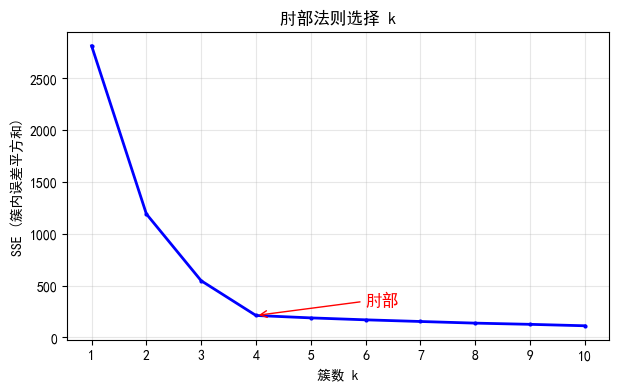

In [26]:
from sklearn.cluster import KMeans
sse_list = []
k_range = range(1, 11)
for k in k_range:
  km = KMeans(
    n_clusters=k,
    init = 'k-means++',
    n_init=10,
    random_state=42,
    )
  km.fit(X)
  sse_list.append(km.inertia_)

plt.figure(figsize=(7,4))
plt.plot(k_range, sse_list, 'bo-', linewidth=2, markersize=2)
plt.xlabel('簇数 k')
plt.ylabel('SSE (簇内误差平方和)')
plt.title('肘部法则选择 k')
plt.xticks(k_range)
plt.grid(True, alpha= 0.3)
plt.annotate('肘部', 
             xy=(4, sse_list[3]), 
             fontsize=12,
             arrowprops=dict(arrowstyle='->', color = 'red'),
             xytext=(6, sse_list[3] + 100), color = 'red'
             )
plt.show()

# KMeans++肘部法则

In [29]:

from sklearn.datasets import make_blobs
# 1. 生成数据
X, y_true = make_blobs(
  n_samples=300,
  centers=4,
  cluster_std=0.8,
  random_state=42,
)

In [30]:
from sklearn.cluster import KMeans
# 2. 运行 K-Means
kmeans = KMeans(
  n_clusters= 4,
  init= 'k-means++',
  n_init=10,
  random_state=42
)
y_pred = kmeans.fit_predict(X)
centroids = kmeans.cluster_centers_ # 获取质心


C:\Users\Gold\AppData\Local\Temp\ipykernel_335968\1811100321.py:18: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(centroids[:, 0], centroids[:, 1], c='red', s=200, marker='x', edgecolors='black', linewidths=1.5, label='质心')


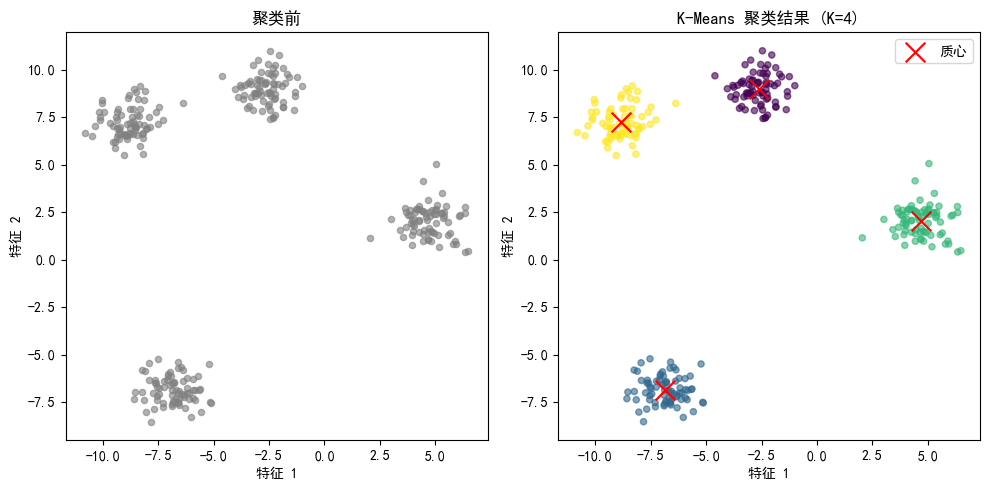

SSE:  362.47
迭代次数: 3


In [31]:
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# 3. 可视化

plt.figure(figsize = (10,5))
## 聚类前
plt.subplot(1, 2, 1)
plt.scatter(X[:, 0], X[:, 1], c='gray', s=20, alpha =0.6)
plt.title('聚类前')
plt.xlabel('特征 1')
plt.ylabel('特征 2')

## 聚类后
plt.subplot(1, 2, 2)
plt.scatter(X[:, 0], X[:, 1], c=y_pred, s=20, cmap='viridis', alpha =0.6)
plt.scatter(centroids[:, 0], centroids[:, 1], c='red', s=200, marker='x', edgecolors='black', linewidths=1.5, label='质心')
plt.title('K-Means 聚类结果 (K=4)')
plt.xlabel('特征 1')
plt.ylabel('特征 2')
plt.legend()

plt.tight_layout()
plt.show()

print(f"SSE: {kmeans.inertia_: .2f}")
print(f"迭代次数: {kmeans.n_iter_}")

# 压缩图片

In [ ]:
## 1. 读取图片并归一化

In [34]:
from skimage import io
# 1. 读取图片并归一化
image = io.imread('materials/img1006RowImg.jpg')
image = image / 255.0 # 归一化到 [0, 1]
h, w, c = image.shape
pixels = image.reshape(-1, 3) # 展平成 （h*w, 3) 像素矩阵

In [ ]:
## 2. 对不同 K 值作压缩

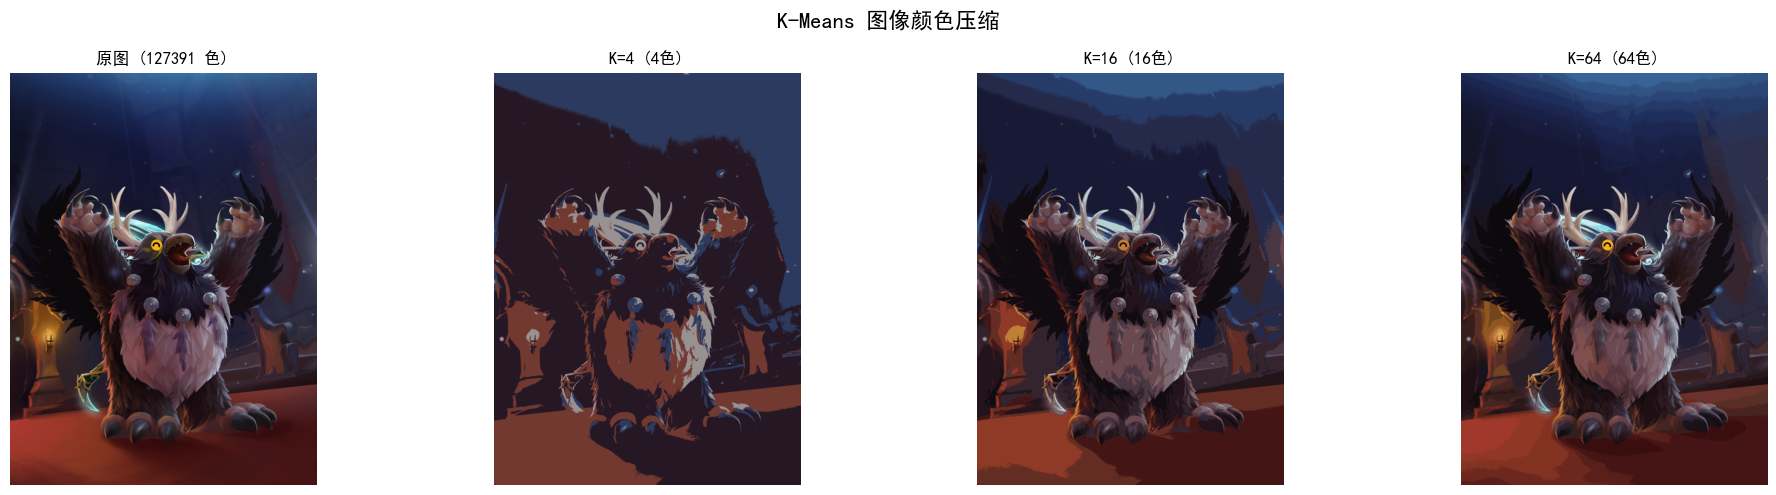

In [35]:
# 2. 对不同 K 值作压缩
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

fig, axes = plt.subplots(1, 4, figsize =(20, 5))
axes[0].imshow(image)
axes[0].set_title(f'原图 ({len(np.unique(pixels, axis=0))} 色)')
axes[0].axis('off')

for idx, k in enumerate([4, 16, 64]):
  km = KMeans(
    n_clusters=k,
    n_init=10,
    random_state=42,
  )
  labels = km.fit_predict(pixels)
  compressed = km.cluster_centers_[labels].reshape(h, w, c)

  axes[idx + 1].imshow(compressed)
  axes[idx + 1].set_title(f'K={k} ({k}色)')
  axes[idx + 1].axis('off')

plt.suptitle('K-Means 图像颜色压缩', fontsize = 16)
plt.tight_layout()
plt.show()